# Application 1 — Non-rigid Shape Registration

Functional maps give a dense vertex-to-vertex correspondence between two shapes.
This correspondence encodes the **registration**: each vertex on the target shape is linked to the
semantically equivalent vertex on the source shape, even across large deformations.

We visualise the registration by transferring a position-based coloring from the source (cat)
to the target (lion) via the recovered point-to-point map.
Consistent colors at anatomically equivalent regions confirm a good registration.

In [1]:
import sys
from pathlib import Path

import gsops.backend as gs
import numpy as np
import pyvista as pv

import geomfum
from geomfum.convert import P2pFromFmConverter
from geomfum.dataset import NotebooksDataset
from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import LandmarkWaveKernelSignature, WaveKernelSignature
from geomfum.functional_map import (
    FactorSum,
    LBCommutativityEnforcing,
    SpectralDescriptorPreservation,
)
from geomfum.numerics.optimization import ScipyMinimize
from geomfum.refine import IcpRefiner
from geomfum.shape import TriangleMesh

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

from plot_utils import pv_faces, show_fmap  # noqa: E402

pv.set_jupyter_backend("static")

## 1. Load shapes

In [2]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(dataset.get_filename("faust-00"))  # source
mesh_b = TriangleMesh.from_file(dataset.get_filename("faust-04"))  # target
print(f"Source (faust-00):  {mesh_a.n_vertices} vertices")
print(f"Target (faust-04): {mesh_b.n_vertices} vertices")

INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-00.off').
INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-04.off').


Source (faust-00):  6890 vertices
Target (faust-04): 6890 vertices


## 2. Compute spectral basis (Laplace-Beltrami eigenfunctions)

In [4]:
k = 200
mesh_a.laplacian.find_spectrum(spectrum_size=k, set_as_basis=True)
mesh_b.laplacian.find_spectrum(spectrum_size=k, set_as_basis=True)
print(f"Spectrum size: {k} eigenfunctions per shape")

Spectrum size: 200 eigenfunctions per shape


## 3. Compute descriptors and optimize the functional map

In [5]:
# Known landmark correspondences (cat → lion)
mesh_a.landmark_indices = gs.array([100, 2000, 3000, 4000, 5000])
mesh_b.landmark_indices = gs.array([100, 2000, 3000, 4000, 5000])
pipeline = DescriptorPipeline(
    [
        WaveKernelSignature(n_domain=200, k=200),
        LandmarkWaveKernelSignature(n_domain=200, k=200),
        ArangeSubsampler(subsample_step=10),
        L2InnerNormalizer(),
    ]
)
descr_a = pipeline.apply(mesh_a)
descr_b = pipeline.apply(mesh_b)

mesh_a.basis.use_k = 30
mesh_b.basis.use_k = 30

factors = [
    SpectralDescriptorPreservation(
        mesh_a.basis.project(descr_a),
        mesh_b.basis.project(descr_b),
        weight=1.0,
    ),
    LBCommutativityEnforcing.from_bases(mesh_a.basis, mesh_b.basis, weight=1e-2),
]
objective = FactorSum(factors)
optimizer = ScipyMinimize(method="L-BFGS-B")
x0 = gs.zeros((mesh_b.basis.use_k, mesh_a.basis.use_k))
res = optimizer.minimize(objective, x0, fun_jac=objective.gradient)
fmap = res.x.reshape(x0.shape)
print(f"Functional map shape: {fmap.shape}  (K_b × K_a)")

Functional map shape: (30, 30)  (K_b × K_a)


## 4. Refine and extract point-to-point correspondence

In [6]:
fmap = IcpRefiner()(fmap, mesh_a.basis, mesh_b.basis)
p2p = P2pFromFmConverter()(fmap, mesh_a.basis, mesh_b.basis)
# p2p[i] = j : vertex i on lion maps to vertex j on cat

## 5. Inspect the functional map matrix

A near-diagonal matrix indicates an accurate, bijective map.

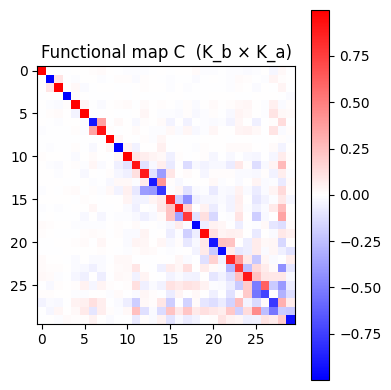

In [7]:
show_fmap(np.array(fmap), title="Functional map C  (K_b × K_a)")

## 6. Visualise the registration via coordinate transfer

We encode the cat's 3-D position as an RGB color and transfer it to the lion via `p2p`.
Semantically corresponding regions (head, body, limbs) should carry the same color on both shapes.

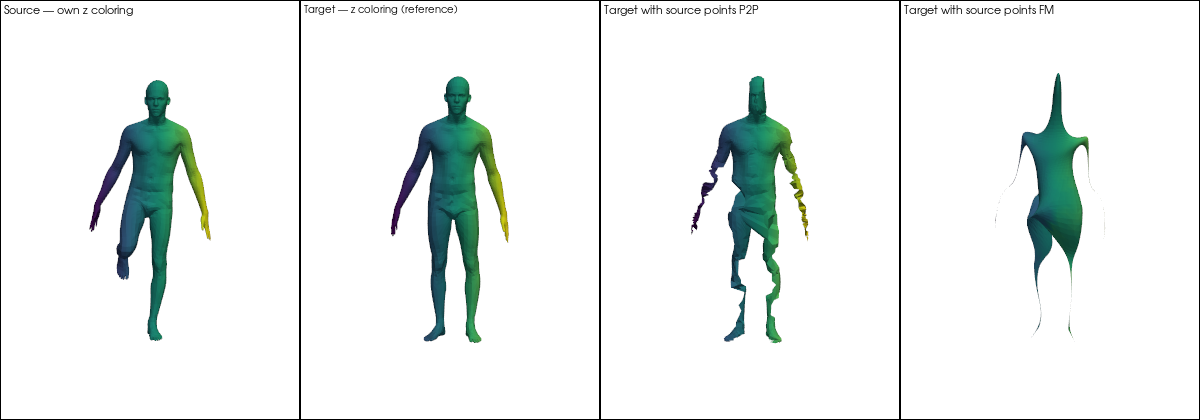

In [8]:
verts_a = np.array(mesh_a.vertices)
verts_b = np.array(mesh_b.vertices)


def normalize(v):
    return (v - v.min()) / (v.max() - v.min())


z_a = normalize(verts_a[:, 0])
z_b = normalize(verts_b[:, 0])
z_b_from_a = z_a[p2p]

pl = pv.Plotter(shape=(1, 4), window_size=(1200, 420))

pv_a = pv.PolyData(verts_a, pv_faces(mesh_a.faces))
pv_a["z"] = z_a
pl.subplot(0, 1)
pl.add_mesh(pv_a, show_scalar_bar=False)
pl.add_text("Target — z coloring (reference)", font_size=8)
pl.camera_position = "xy"

pv_b1 = pv.PolyData(verts_b, pv_faces(mesh_b.faces))
pv_b1["z"] = z_b
pl.subplot(0, 0)
pl.add_mesh(pv_b1, show_scalar_bar=False)
pl.add_text("Source — own z coloring", font_size=8)
pl.camera_position = "xy"

pv_b2 = pv.PolyData(verts_a[p2p], pv_faces(mesh_b.faces))
pv_b2["z_cat"] = z_b_from_a
pl.subplot(0, 2)
pl.add_mesh(pv_b2, show_scalar_bar=False)
pl.add_text("Target with source points P2P", font_size=8)
pl.camera_position = "xy"

pv_b2 = pv.PolyData(
    mesh_b.basis.vecs @ fmap @ mesh_a.basis.pinv @ verts_a,
    pv_faces(mesh_b.faces),
)
pv_b2["z_cat"] = z_b_from_a
pl.subplot(0, 3)
pl.add_mesh(pv_b2, show_scalar_bar=False)
pl.add_text("Target with source points FM", font_size=8)
pl.camera_position = "xy"

pl.show()

The right panel should match the middle panel: the FM registration correctly links
top-of-head to top-of-head, legs to legs, and so on, despite the large shape difference.